# Base 5 — ouro semanal: Random Forest para Retorno do ouro + Calculo para preço

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller


def find_project_root(start):
    for candidate in (start, *start.parents):
        if ((candidate / 'projeto.yaml').is_file() or
                (candidate / 'config' / 'projeto.yaml').is_file()):
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')


ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from series_temporais.data.preparacao_base5 import (
    construir_quadro_ouro,
    preparar_ouro_semanal,
    selecionar_alvos_observados,
)
from series_temporais.validation.temporal_split import purged_time_series_splits

In [2]:
BASE_DIR = ROOT / 'data/base_05'
DATA_PATH = BASE_DIR / 'raw.csv'
WEEKLY_RULE = 'W-FRI'
STL_PERIOD = 52
TRAIN_RATIO = .75
RANDOM_STATE = 42
REFIT_EVERY = 1
TARGET = 'target_log_return_t_plus_1'
np.random.seed(RANDOM_STATE)


## 2. Ingestão e auditoria do CSV atual

Somente `DATE`, `GOLD_PRICE`, `TREASURY_10Y` e `FED_FUNDS_RATE` alimentam a
reconstrução. As derivações entregues são auditadas, mas excluídas do modelo,
pois foram calculadas em outra grade temporal.

In [3]:
expected_columns = [
    'DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE', 'DAY_OF_WEEK',
    'MONTH', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'GOLD_LAG_1',
    'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5',
    'GOLD_ROLLING_STD_5', 'TARGET',
]
derived_source_columns = expected_columns[4:]
df_raw = pd.read_csv(DATA_PATH, dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = df_raw.copy()
df['DATE'] = pd.to_datetime(df.DATE, format='%Y-%m-%d', errors='raise')
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)
next_row_match = np.isclose(df.TARGET.iloc[:-1], df.GOLD_PRICE.shift(-1).iloc[:-1], equal_nan=False).mean()
lag_1_match = np.isclose(df.GOLD_LAG_1.iloc[1:], df.GOLD_PRICE.shift(1).iloc[1:], equal_nan=False).mean()
quality_report = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'linhas': len(df), 'colunas': len(df.columns),
    'primeira_data': df.DATE.min(), 'ultima_data': df.DATE.max(),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'valores_nulos': int(df.isna().sum().sum()),
    'precos_nao_positivos': int(df.GOLD_PRICE.le(0).sum()),
    'TARGET_igual_proxima_linha_fracao': next_row_match,
    'GOLD_LAG_1_igual_shift_fracao': lag_1_match,
}, name='valor').to_frame()
assert df.DATE.is_unique and df.GOLD_PRICE.gt(0).all()
display(quality_report)
display(df.head())

,valor
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
linhas,9864
colunas,16
primeira_data,1968-04-29 00:00:00
ultima_data,2014-04-09 00:00:00
datas_nulas,0
datas_duplicadas,0
valores_nulos,0
precos_nao_positivos,0


,DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DAY_OF_WEEK,MONTH,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TARGET
0,1968-04-29,38.55,5.71,6.13,0,4,0.000000,1.000000,0.866025,-0.500000,38.50,38.30,38.0,38.29,0.163554,39.10
1,1968-04-30,39.10,5.73,6.13,1,4,0.781831,0.623490,0.866025,-0.500000,38.55,38.05,37.6,38.34,0.201246,39.10
2,1968-05-01,39.10,5.74,6.25,2,5,0.974928,-0.222521,0.500000,-0.866025,39.10,38.35,37.7,38.55,0.329773,39.25
3,1968-05-02,39.25,5.73,6.38,3,5,0.433884,-0.900969,0.500000,-0.866025,39.10,38.25,36.7,38.70,0.382426,39.60
4,1968-05-03,39.60,5.76,6.25,4,5,-0.433884,-0.900969,0.500000,-0.866025,39.25,38.50,37.2,38.90,0.348210,39.70


## 3. Limpeza e preparação semanal causal

Cada sexta-feira representa a origem semanal. Em semanas vazias, somente o
último estado já conhecido é carregado para frente; data da última cotação,
idade e indicador de carregamento permanecem explícitos.

In [4]:
weekly = preparar_ouro_semanal(df, WEEKLY_RULE)
weekly_quality = pd.Series({
    'semanas': len(weekly), 'primeira_semana': weekly.DATE.min(),
    'ultima_semana': weekly.DATE.max(),
    'semanas_sem_linha_de_origem': int(weekly.price_was_carried.sum()),
    'maior_idade_da_cotacao_em_dias': int(weekly.quote_age_days.max()),
    'menor_preco': weekly.price_t.min(), 'maior_preco': weekly.price_t.max(),
    'min_observacoes_por_semana': int(weekly.source_observations.min()),
    'max_observacoes_por_semana': int(weekly.source_observations.max()),
}, name='valor').to_frame()
assert weekly.DATE.diff().dropna().dt.days.eq(7).all()
display(weekly_quality)
display(weekly.head())

,valor
semanas,2398
primeira_semana,1968-05-03 00:00:00
ultima_semana,2014-04-11 00:00:00
semanas_sem_linha_de_origem,254
maior_idade_da_cotacao_em_dias,17
menor_preco,34.775
maior_preco,1879.5
min_observacoes_por_semana,0
max_observacoes_por_semana,5


,DATE,price_t,treasury_10y_t,fed_funds_rate_t,source_observations,last_quote_date,price_was_carried,quote_age_days,log_price_t,log_return_t
0,1968-05-03,39.60,5.76,6.25,5,1968-05-03,False,0,3.678829,NaN
1,1968-05-10,39.70,5.80,5.50,4,1968-05-09,False,1,3.681351,0.002522
2,1968-05-17,41.60,5.90,6.38,4,1968-05-17,False,0,3.728100,0.046749
3,1968-05-24,41.75,5.98,6.25,5,1968-05-24,False,0,3.731699,0.003599
4,1968-05-31,41.75,5.95,5.75,4,1968-05-30,False,1,3.731699,0.000000


## 4. Gráficos exploratórios

Os gráficos preservam picos e tornam visíveis retorno, taxas, volatilidade e
cobertura. Nenhuma observação é removida por parecer extrema.

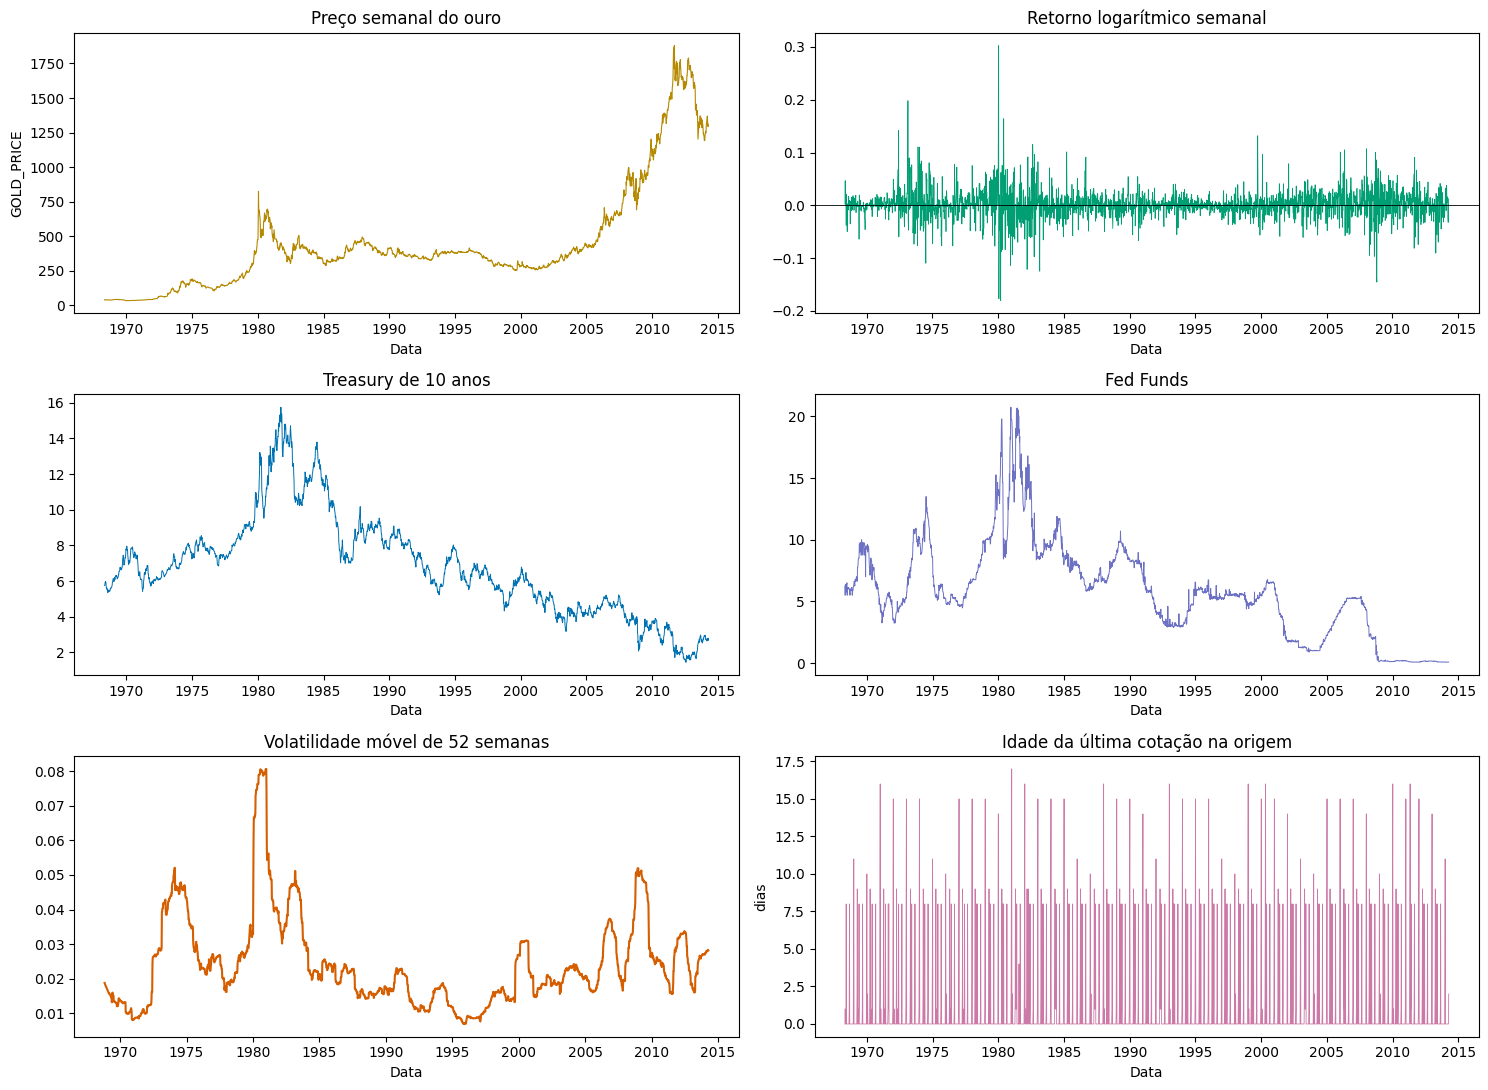

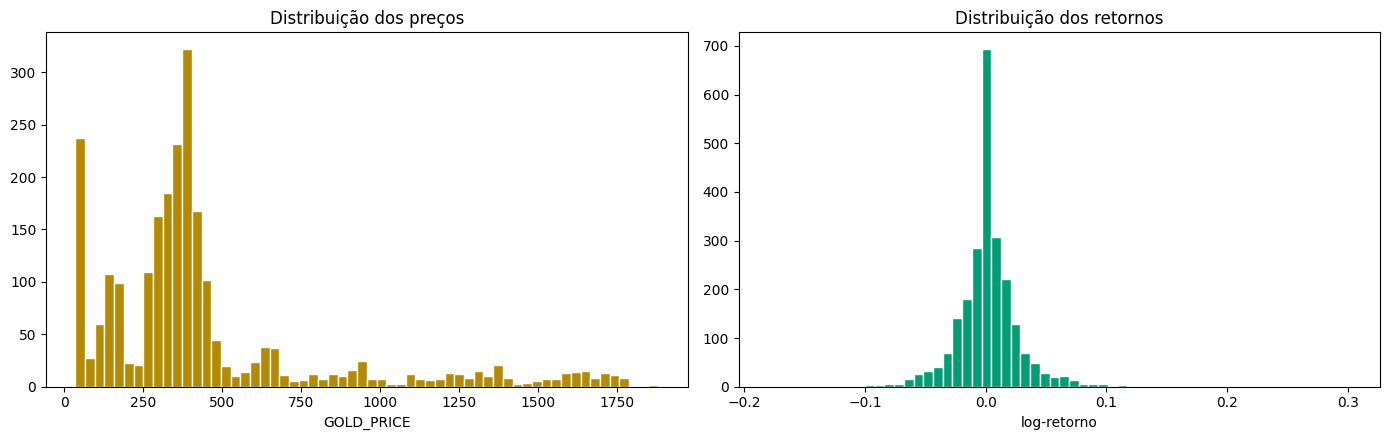

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes[0, 0].plot(weekly.DATE, weekly.price_t, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço semanal do ouro', ylabel='GOLD_PRICE')
axes[0, 1].plot(weekly.DATE, weekly.log_return_t, lw=.55, color='#009e73')
axes[0, 1].axhline(0, color='black', lw=.6); axes[0, 1].set(title='Retorno logarítmico semanal')
axes[1, 0].plot(weekly.DATE, weekly.treasury_10y_t, lw=.7, color='#0072b2')
axes[1, 0].set(title='Treasury de 10 anos')
axes[1, 1].plot(weekly.DATE, weekly.fed_funds_rate_t, lw=.7, color='#6c71c4')
axes[1, 1].set(title='Fed Funds')
axes[2, 0].plot(weekly.DATE, weekly.log_return_t.rolling(52, min_periods=26).std(), color='#d55e00')
axes[2, 0].set(title='Volatilidade móvel de 52 semanas')
axes[2, 1].plot(weekly.DATE, weekly.quote_age_days, lw=.6, color='#cc79a7')
axes[2, 1].set(title='Idade da última cotação na origem', ylabel='dias')
for ax in axes.flat: ax.set_xlabel('Data')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(weekly.price_t, bins=60, edgecolor='white', color='#b58900')
axes[0].set(title='Distribuição dos preços', xlabel='GOLD_PRICE')
axes[1].hist(weekly.log_return_t.dropna(), bins=60, edgecolor='white', color='#009e73')
axes[1].set(title='Distribuição dos retornos', xlabel='log-retorno')
plt.tight_layout(); plt.show()

## 5. STL e força da sazonalidade

A STL robusta usa apenas os 75% iniciais da série semanal. A força sazonal é
`max(0, 1 - Var(R) / Var(S + R))`; a força da tendência usa fórmula análoga.

,componente,forca,periodo_stl
0,sazonalidade,0.000000,52
1,tendência,0.927517,52


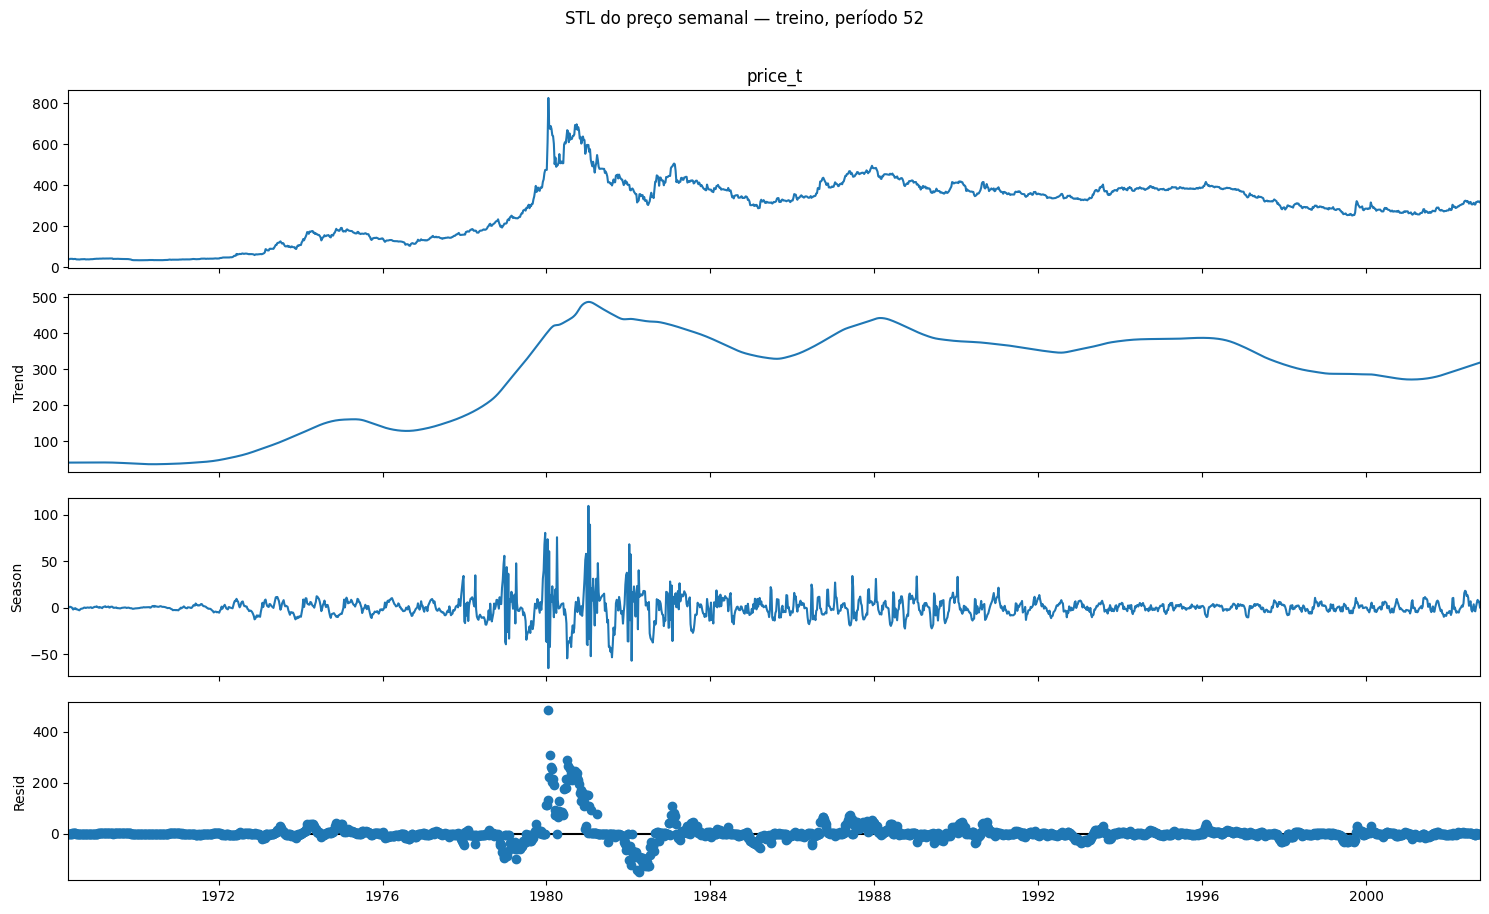

Interpretação: força sazonal 0.000 e força de tendência 0.928. A tendência apresenta crescimento líquido de 277.43 unidades no treino. O resíduo concentra variação não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.


In [6]:
stl_cut = int(len(weekly) * TRAIN_RATIO)
stl_series = weekly.iloc[:stl_cut].set_index('DATE').price_t.asfreq(WEEKLY_RULE)
assert stl_series.notna().all() and len(stl_series) >= 2 * STL_PERIOD
stl_result = STL(stl_series, period=STL_PERIOD, robust=True).fit()
resid_var = np.var(stl_result.resid, ddof=1)
seasonal_strength = max(0., 1. - resid_var / np.var(stl_result.seasonal + stl_result.resid, ddof=1))
trend_strength = max(0., 1. - resid_var / np.var(stl_result.trend + stl_result.resid, ddof=1))
display(pd.DataFrame({
    'componente': ['sazonalidade', 'tendência'],
    'forca': [seasonal_strength, trend_strength], 'periodo_stl': STL_PERIOD,
}))
fig = stl_result.plot(); fig.set_size_inches(15, 9)
fig.suptitle('STL do preço semanal — treino, período 52', y=1.01)
plt.tight_layout(); plt.show()
trend_change = float(stl_result.trend.iloc[-1] - stl_result.trend.iloc[0])
trend_direction = 'crescimento' if trend_change > 0 else 'queda' if trend_change < 0 else 'estabilidade'
print(
    f'Interpretação: força sazonal {seasonal_strength:.3f} e força de tendência '
    f'{trend_strength:.3f}. A tendência apresenta {trend_direction} líquido de '
    f'{abs(trend_change):.2f} unidades no treino. O resíduo concentra variação '
    'não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.'
)

## 6. Features, corte temporal, ADF, ACF e PACF

Lags e janelas são reconstruídos depois da agregação semanal. Datas-alvo,
preço futuro e todas as derivações entregues no CSV ficam fora de `X`.
Somente semanas-alvo com cotação nova entram no tuning e no ajuste. O indicador de disponibilidade do alvo nunca entra em `X`.


,recorte,linhas,inicio_origem,fim_origem
0,treino — grade,1757,1969-05-09,2003-01-03
1,treino — alvos observados,1570,1969-05-09,2003-01-03
2,teste — grade,586,2003-01-17,2014-04-04


,serie,estatistica,p_valor,lags
0,log do preço semanal — treino,-2.511253,1.127602e-01,8
1,retorno log semanal — treino,-14.203771,1.769288e-26,7


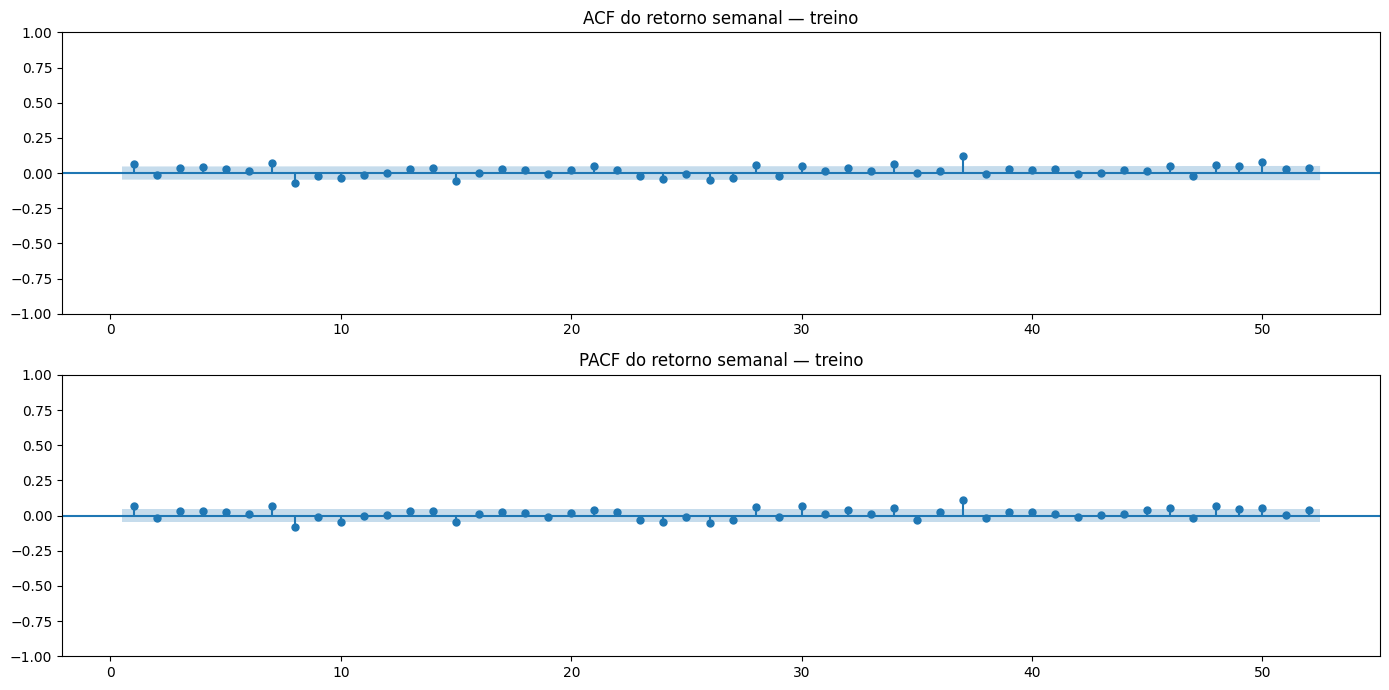

In [7]:
model_df, feature_columns = construir_quadro_ouro(weekly)
split_index = int(len(model_df) * TRAIN_RATIO)
first_test_origin = model_df.iloc[split_index].DATE
train_df = model_df.iloc[:split_index].loc[lambda x: x.target_date < first_test_origin].reset_index(drop=True)
test_df = model_df.iloc[split_index:].reset_index(drop=True)
training_df = selecionar_alvos_observados(train_df)
X_train, y_train = training_df[feature_columns], training_df[TARGET]
X_test, y_test = test_df[feature_columns], test_df[TARGET]
assert train_df.target_date.max() < test_df.DATE.min()
assert not set(derived_source_columns).intersection(feature_columns)
assert 'target_has_new_quote' not in feature_columns
assert training_df.target_has_new_quote.eq(1).all()

def adf_row(name, series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'serie': name, 'estatistica': result[0], 'p_valor': result[1], 'lags': result[2]}
display(pd.DataFrame({
    'recorte': ['treino — grade', 'treino — alvos observados', 'teste — grade'],
    'linhas': [len(train_df), len(training_df), len(test_df)],
    'inicio_origem': [train_df.DATE.min(), training_df.DATE.min(), test_df.DATE.min()],
    'fim_origem': [train_df.DATE.max(), training_df.DATE.max(), test_df.DATE.max()],
}))
display(pd.DataFrame([
    adf_row('log do preço semanal — treino', train_df.log_price_t),
    adf_row('retorno log semanal — treino', train_df.log_return_t),
]))
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_df.log_return_t, lags=52, zero=False, ax=axes[0])
plot_pacf(train_df.log_return_t, lags=52, zero=False, method='ywm', ax=axes[1])
axes[0].set_title('ACF do retorno semanal — treino')
axes[1].set_title('PACF do retorno semanal — treino')
plt.tight_layout(); plt.show()

## 7. Otimização temporal do Random Forest

O desenho investiga explicitamente `n_estimators`, `max_depth`,
`min_samples_split`, `min_samples_leaf` e `max_features` em três dobras
expansivas purgadas. O teste final não participa da seleção.

In [8]:
candidates = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': .7},
]
cv_splits = purged_time_series_splits(training_df.DATE, training_df.target_date, n_splits=3)
search_rows = []
search_start = time.perf_counter()
for candidate_id, params in enumerate(candidates, start=1):
    fold_maes, fold_seconds = [], []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        candidate = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        fold_start = time.perf_counter()
        candidate.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        prediction = candidate.predict(X_train.iloc[validation_idx])
        fold_seconds.append(time.perf_counter() - fold_start)
        fold_maes.append(mean_absolute_error(y_train.iloc[validation_idx], prediction))
    search_rows.append({
        'candidate_id': candidate_id, **params,
        'mean_validation_mae': np.mean(fold_maes),
        'std_validation_mae': np.std(fold_maes, ddof=1),
        'fit_seconds': np.sum(fold_seconds),
    })
search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae', 'std_validation_mae', 'candidate_id']
).reset_index(drop=True)
best_params = {key: search_results.iloc[0][key] for key in candidates[0]}
for key in ('n_estimators', 'min_samples_split', 'min_samples_leaf'):
    best_params[key] = int(best_params[key])
best_params['max_depth'] = None if pd.isna(best_params['max_depth']) else int(best_params['max_depth'])
display(search_results)
print('Melhores parâmetros:', best_params)
print(f'Tempo de busca: {search_seconds:.2f} s')

,candidate_id,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mean_validation_mae,std_validation_mae,fit_seconds
0,6,250,6.0,2,3,sqrt,0.018956,0.010455,2.440270
1,3,100,6.0,2,1,sqrt,0.019706,0.011274,1.465366
2,5,100,NaN,2,3,sqrt,0.019743,0.010877,1.516014
3,8,250,6.0,10,3,0.7,0.019861,0.011427,4.637932
4,4,100,12.0,10,1,sqrt,0.020322,0.011761,1.542752
5,2,250,NaN,2,1,sqrt,0.021075,0.011784,4.838223
6,1,100,NaN,2,1,sqrt,0.021192,0.012068,2.187659
7,9,250,12.0,5,2,0.7,0.021679,0.012560,7.212325
8,7,100,NaN,2,1,0.7,0.022982,0.013194,4.185461


Melhores parâmetros: {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}
Tempo de busca: 30.09 s


## 8. Walk-forward final e importância das features

Os parâmetros permanecem fixos. O modelo é reajustado em cada origem de teste.
Cada ajuste usa somente alvos já revelados e com cotação nova, mas todas as 586
origens recebem uma previsão fora da amostra.


,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,has_source_observation_t,y_pred_return_rf,model_refit_origin,training_target_cutoff,y_pred_return_zero,price_pred_rf,price_pred_persistence,residual_return_rf,residual_price_rf,absolute_error_price_rf
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,1,0.002540,2003-01-17,2003-01-10,0.0,359.110904,358.20,0.013797,4.989096,4.989096
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,1,0.002816,2003-01-24,2003-01-24,0.0,365.126637,364.10,0.014204,5.223363,5.223363
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,1,0.002790,2003-01-31,2003-01-31,0.0,371.384797,370.35,-0.002250,-0.834797,0.834797
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,1,0.003256,2003-02-07,2003-02-07,0.0,371.758388,370.55,-0.042611,-15.508388,15.508388
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,1,0.000680,2003-02-14,2003-02-14,0.0,356.492197,356.25,-0.007015,-2.492197,2.492197


,feature,importance_mean,importance_std,grupo
0,return_mean_52,0.073839,0.002606,historico_ou_cobertura
1,log_return_t,0.054489,0.004413,historico_ou_cobertura
2,return_mean_26,0.041026,0.004739,historico_ou_cobertura
3,return_lag_26,0.037392,0.004430,historico_ou_cobertura
4,return_lag_2,0.031158,0.002776,historico_ou_cobertura
5,return_mean_13,0.030260,0.003182,historico_ou_cobertura
6,fed_funds_lag_4,0.028681,0.004778,externa_na_origem
7,price_std_13,0.028585,0.003099,historico_ou_cobertura
8,return_std_13,0.028372,0.002634,historico_ou_cobertura
9,return_lag_13,0.027185,0.002322,historico_ou_cobertura


,grupo,importance_mean
0,calendario,0.039481
1,externa_na_origem,0.170451
2,historico_ou_cobertura,0.790067


Externas mais importantes (importância nativa, não causal):


,feature,importance_mean,importance_std,grupo
6,fed_funds_lag_4,0.028681,0.004778,externa_na_origem
15,fed_funds_lag_1,0.022932,0.002885,externa_na_origem
20,fed_funds_rate_t,0.020288,0.002385,externa_na_origem
26,fed_funds_change_t,0.016927,0.001406,externa_na_origem
29,treasury_10y_t,0.015512,0.001579,externa_na_origem
30,fed_funds_lag_13,0.015347,0.001945,externa_na_origem
31,treasury_lag_1,0.014714,0.001615,externa_na_origem
35,treasury_lag_4,0.012776,0.001504,externa_na_origem


Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; nenhuma taxa observada da semana-alvo entra em X.


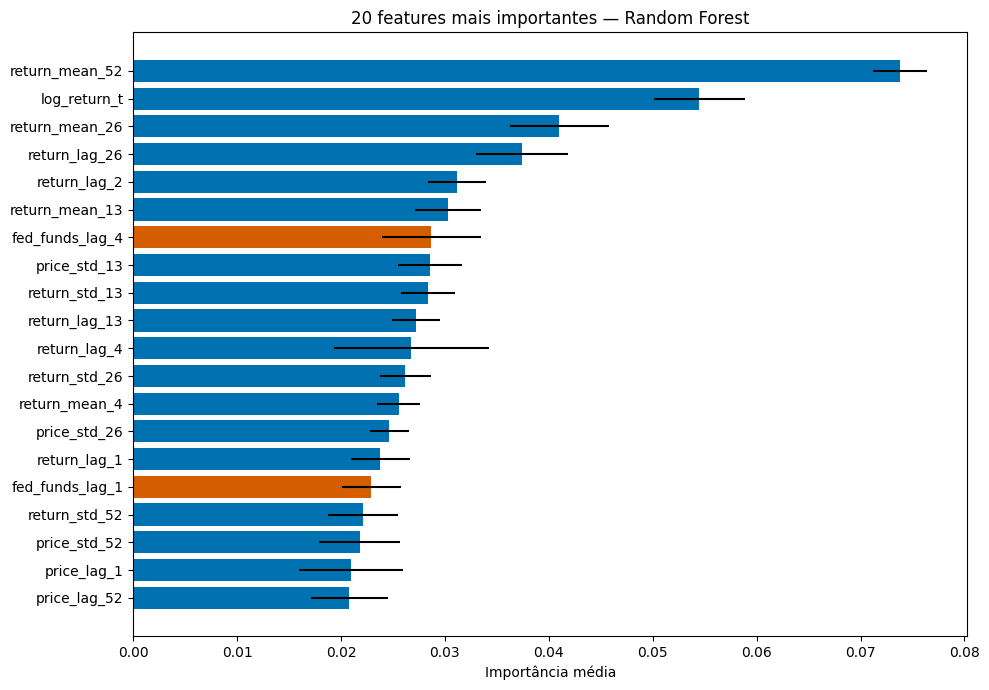

In [9]:
prediction_values, prediction_refits, training_cutoffs = [], [], []
fit_rows, importance_rows = [], []
evaluation_start = time.perf_counter()
for block_start in range(0, len(test_df), REFIT_EVERY):
    block_end = min(block_start + REFIT_EVERY, len(test_df))
    current_origin = test_df.iloc[block_start].DATE
    known_test = test_df.target_date <= current_origin
    history_all = pd.concat([train_df, test_df.loc[known_test]], ignore_index=True)
    history = selecionar_alvos_observados(history_all)
    assert history.target_has_new_quote.eq(1).all()
    model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    fit_start = time.perf_counter()
    model.fit(history[feature_columns], history[TARGET])
    prediction_values.extend(model.predict(X_test.iloc[block_start:block_end]))
    prediction_refits.extend([current_origin] * (block_end - block_start))
    training_cutoff = history.target_date.max()
    training_cutoffs.extend([training_cutoff] * (block_end - block_start))
    fit_rows.append({
        'origem_refit': current_origin, 'linhas_historico_revelado': len(history_all),
        'linhas_alvos_observados': len(history),
        'inicio_bloco': block_start, 'fim_bloco_exclusivo': block_end,
        'fit_seconds': time.perf_counter() - fit_start,
    })
    importance_rows.append(model.feature_importances_)
evaluation_seconds = time.perf_counter() - evaluation_start
predictions = test_df[['DATE', 'target_date', 'price_t', 'target_price_t_plus_1', TARGET, 'target_has_new_quote', 'has_source_observation_t']].copy()
predictions = predictions.rename(columns={TARGET: 'y_true_return'})
predictions['y_pred_return_rf'] = np.asarray(prediction_values)
predictions['model_refit_origin'] = prediction_refits
predictions['training_target_cutoff'] = training_cutoffs
assert (predictions.training_target_cutoff <= predictions.DATE).all()
predictions['y_pred_return_zero'] = 0.
predictions['price_pred_rf'] = predictions.price_t * np.exp(predictions.y_pred_return_rf)
predictions['price_pred_persistence'] = predictions.price_t
predictions['residual_return_rf'] = predictions.y_true_return - predictions.y_pred_return_rf
predictions['residual_price_rf'] = predictions.target_price_t_plus_1 - predictions.price_pred_rf
predictions['absolute_error_price_rf'] = predictions.residual_price_rf.abs()
observed_predictions = predictions.loc[predictions.target_has_new_quote.eq(1)].copy()
fit_log = pd.DataFrame(fit_rows)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance_mean': np.mean(importance_rows, axis=0),
    'importance_std': np.std(importance_rows, axis=0),
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
external_prefixes = ('treasury_', 'fed_funds_')
feature_importance['grupo'] = np.select(
    [feature_importance.feature.str.startswith(external_prefixes),
     feature_importance.feature.str.startswith(('price_', 'return_', 'log_', 'source_', 'quote_', 'weeks_'))],
    ['externa_na_origem', 'historico_ou_cobertura'], default='calendario',
)
display(predictions.head())
display(feature_importance.head(20))
display(feature_importance.groupby('grupo', as_index=False).importance_mean.sum())
print('Externas mais importantes (importância nativa, não causal):')
display(feature_importance.loc[feature_importance.grupo.eq('externa_na_origem')].head(8))
print(
    'Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; '
    'nenhuma taxa observada da semana-alvo entra em X.'
)
fig, ax = plt.subplots(figsize=(10, 7))
top = feature_importance.head(20).sort_values('importance_mean')
palette = {'externa_na_origem': '#d55e00', 'historico_ou_cobertura': '#0072b2', 'calendario': '#009e73'}
ax.barh(top.feature, top.importance_mean, xerr=top.importance_std,
        color=top.grupo.map(palette))
ax.set(title='20 features mais importantes — Random Forest', xlabel='Importância média')
plt.tight_layout(); plt.show()

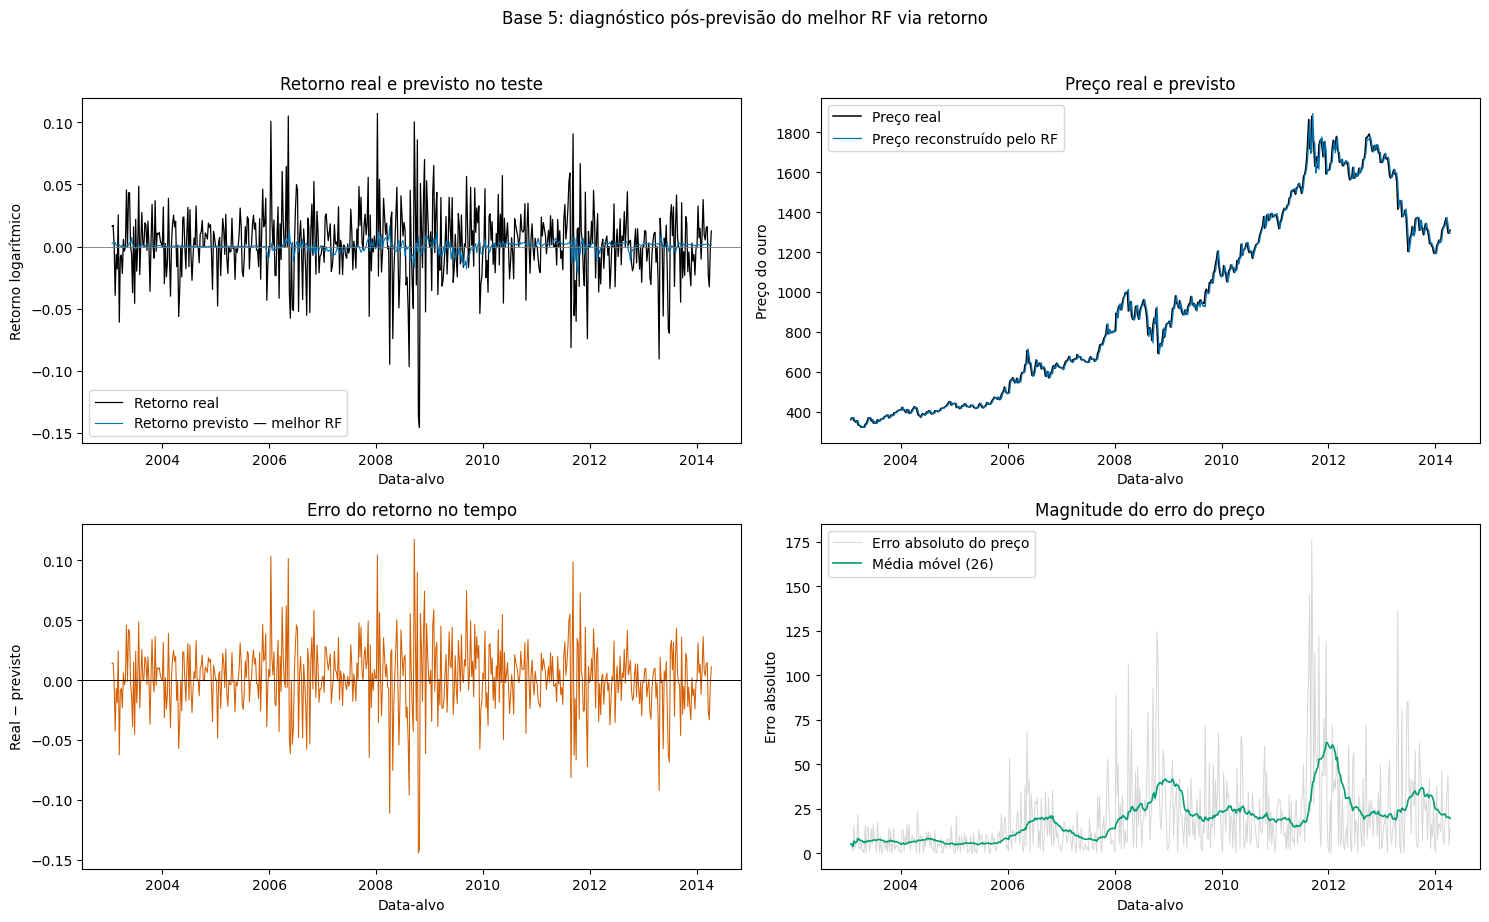

In [10]:
# Diagnóstico visual fora da amostra do melhor RF ajustado no retorno
diagnostic_window = min(26, max(5, len(predictions) // 10))
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(predictions.target_date, predictions.y_true_return, label='Retorno real', color='black', lw=.9)
axes[0, 0].plot(predictions.target_date, predictions.y_pred_return_rf, label='Retorno previsto — melhor RF', color='#0072b2', lw=.8)
axes[0, 0].axhline(0, color='#777777', lw=.6)
axes[0, 0].set(title='Retorno real e previsto no teste', xlabel='Data-alvo', ylabel='Retorno logarítmico')
axes[0, 0].legend()

axes[0, 1].plot(predictions.target_date, predictions.target_price_t_plus_1, label='Preço real', color='black', lw=1.1)
axes[0, 1].plot(predictions.target_date, predictions.price_pred_rf, label='Preço reconstruído pelo RF', color='#0072b2', lw=.9)
axes[0, 1].set(title='Preço real e previsto', xlabel='Data-alvo', ylabel='Preço do ouro')
axes[0, 1].legend()

axes[1, 0].plot(predictions.target_date, predictions.residual_return_rf, color='#d55e00', lw=.75)
axes[1, 0].axhline(0, color='black', lw=.7)
axes[1, 0].set(title='Erro do retorno no tempo', xlabel='Data-alvo', ylabel='Real − previsto')

axes[1, 1].plot(predictions.target_date, predictions.absolute_error_price_rf, color='#999999', alpha=.4, lw=.7, label='Erro absoluto do preço')
axes[1, 1].plot(predictions.target_date, predictions.absolute_error_price_rf.rolling(diagnostic_window, min_periods=1).mean(), color='#009e73', lw=1.2, label=f'Média móvel ({diagnostic_window})')
axes[1, 1].set(title='Magnitude do erro do preço', xlabel='Data-alvo', ylabel='Erro absoluto')
axes[1, 1].legend()

fig.suptitle('Base 5: diagnóstico pós-previsão do melhor RF via retorno', y=1.02)
plt.tight_layout(); plt.show()

## 9. MAE e demais métricas
A avaliação principal usa semanas-alvo com cotação nova. A grade completa é apresentada somente como sensibilidade; o recorte com cotação na origem e no alvo é uma robustez adicional.


In [11]:
def metric_row(name, return_prediction, price_prediction, subset=None):
    mask = pd.Series(True, index=predictions.index) if subset is None else subset
    actual_return = predictions.loc[mask, 'y_true_return']
    predicted_return = np.asarray(return_prediction)[mask.to_numpy()]
    actual_price = predictions.loc[mask, 'target_price_t_plus_1']
    predicted_price = np.asarray(price_prediction)[mask.to_numpy()]
    return {
        'modelo': name, 'observacoes': int(mask.sum()),
        'MAE_retorno': mean_absolute_error(actual_return, predicted_return),
        'RMSE_retorno': mean_squared_error(actual_return, predicted_return) ** .5,
        'MedAE_retorno': median_absolute_error(actual_return, predicted_return),
        'R2_retorno': r2_score(actual_return, predicted_return),
        'vies_retorno': np.mean(actual_return - predicted_return),
        'acuracia_direcional': np.mean(np.sign(actual_return) == np.sign(predicted_return)),
        'MAE_preco': mean_absolute_error(actual_price, predicted_price),
    }
new_quote = predictions.target_has_new_quote.eq(1)
origin_and_target_quote = predictions.has_source_observation_t.eq(1) & new_quote
metrics = pd.DataFrame([
    metric_row('Random Forest — nova cotação', predictions.y_pred_return_rf, predictions.price_pred_rf, new_quote),
    metric_row('Persistência — nova cotação', predictions.y_pred_return_zero, predictions.price_pred_persistence, new_quote),
    metric_row('Random Forest — origem e alvo com cotação', predictions.y_pred_return_rf, predictions.price_pred_rf, origin_and_target_quote),
    metric_row('Persistência — origem e alvo com cotação', predictions.y_pred_return_zero, predictions.price_pred_persistence, origin_and_target_quote),
    metric_row('Random Forest — todas (sensibilidade)', predictions.y_pred_return_rf, predictions.price_pred_rf),
    metric_row('Persistência — todas (sensibilidade)', predictions.y_pred_return_zero, predictions.price_pred_persistence),
])
metrics['skill_mae_preco_vs_persistencia'] = np.nan
for suffix in ('nova cotação', 'origem e alvo com cotação', 'todas (sensibilidade)'):
    baseline_mae = metrics.loc[metrics.modelo.eq(f'Persistência — {suffix}'), 'MAE_preco'].iloc[0]
    scope = metrics.modelo.str.endswith(suffix)
    metrics.loc[scope, 'skill_mae_preco_vs_persistencia'] = 1 - metrics.loc[scope, 'MAE_preco'] / baseline_mae
display(metrics)


,modelo,observacoes,MAE_retorno,RMSE_retorno,MedAE_retorno,R2_retorno,vies_retorno,acuracia_direcional,MAE_preco,skill_mae_preco_vs_persistencia
0,Random Forest — nova cotação,523,0.022734,0.030708,0.018216,-0.048026,0.002384,0.499044,21.443066,-0.009803
1,Persistência — nova cotação,523,0.022522,0.030098,0.018257,-0.006830,0.002479,0.001912,21.234895,0.000000
2,Random Forest — origem e alvo com cotação,469,0.021368,0.028660,0.017800,-0.036683,0.001467,0.496802,20.365780,-0.009635
3,Persistência — origem e alvo com cotação,469,0.021185,0.028185,0.017469,-0.002649,0.001449,0.002132,20.171429,0.000000
4,Random Forest — todas (sensibilidade),586,0.020569,0.029039,0.015908,-0.049367,0.002151,0.445392,19.427391,-0.025086
5,Persistência — todas (sensibilidade),586,0.020101,0.028434,0.016044,-0.006091,0.002212,0.109215,18.951962,0.000000


## 10. Registro de parâmetros, versões e tempo

O registro reúne hash, configuração, features, parâmetros, versões, tempos e
cada reajuste do teste para reprodução completa.

In [12]:
experiment_record = pd.DataFrame([{
    'base': 'Base 5 — ouro semanal', 'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash, 'frequencia': WEEKLY_RULE,
    'alvo': TARGET, 'horizonte_provisorio': '1 semana',
    'split_treino': TRAIN_RATIO, 'random_state': RANDOM_STATE,
    'linhas_treino_grade': len(train_df), 'linhas_treino_alvo_observado': len(training_df),
    'linhas_teste': len(test_df), 'linhas_teste_alvo_observado': int(test_df.target_has_new_quote.sum()),
    'linhas_teste_origem_e_alvo_observados': int((test_df.has_source_observation_t.eq(1) & test_df.target_has_new_quote.eq(1)).sum()),
    'origem_teste_inicial': test_df.DATE.min(), 'origem_teste_final': test_df.DATE.max(),
    'numero_features': len(feature_columns),
    'features': json.dumps(feature_columns, ensure_ascii=False),
    'candidatos_tuning': len(candidates), 'dobras_validacao': len(cv_splits),
    'melhores_parametros': json.dumps(best_params, ensure_ascii=False),
    'tempo_busca_s': search_seconds, 'tempo_walk_forward_s': evaluation_seconds,
    'numero_refits_teste': len(fit_log), 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit_learn': sklearn.__version__, 'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 5 — ouro semanal
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
frequencia,W-FRI
alvo,target_log_return_t_plus_1
horizonte_provisorio,1 semana
split_treino,0.75
random_state,42
linhas_treino_grade,1757
linhas_treino_alvo_observado,1570


,origem_refit,linhas_historico_revelado,linhas_alvos_observados,inicio_bloco,fim_bloco_exclusivo,fit_seconds
0,2003-01-17,1757,1570,0,1,1.325170
1,2003-01-24,1758,1571,1,2,1.954485
2,2003-01-31,1759,1572,2,3,1.907018
3,2003-02-07,1760,1573,3,4,1.237154
4,2003-02-14,1761,1574,4,5,1.847651
...,...,...,...,...,...,...
581,2014-03-07,2338,2088,581,582,1.522358
582,2014-03-14,2339,2089,582,583,1.578627
583,2014-03-21,2340,2090,583,584,1.731920
584,2014-03-28,2341,2091,584,585,1.656677


## 11. Resíduos individuais
Os diagnósticos residuais usam somente semanas-alvo com cotação efetivamente observada.


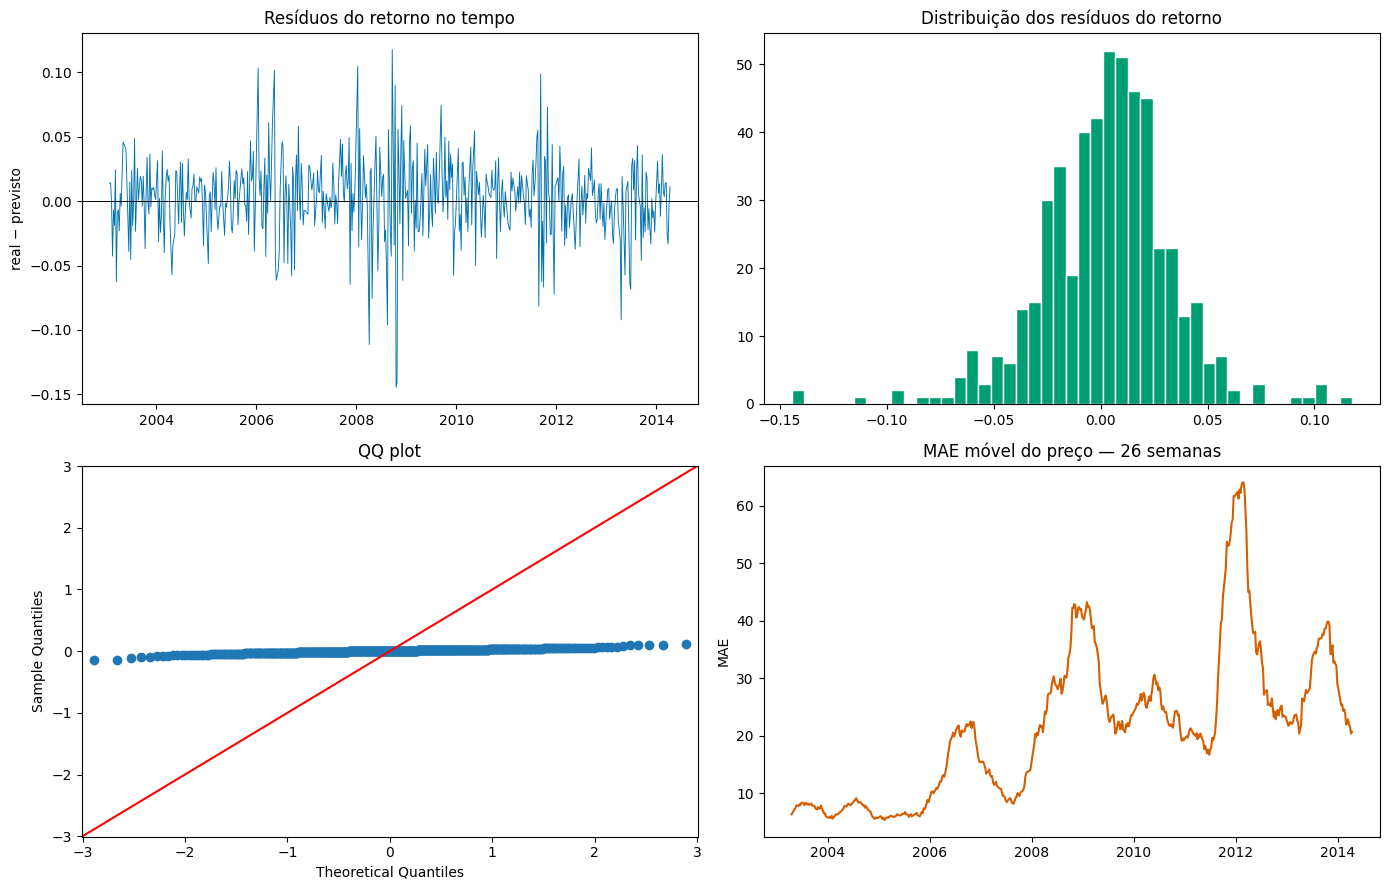

,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,has_source_observation_t,y_pred_return_rf,model_refit_origin,training_target_cutoff,y_pred_return_zero,price_pred_rf,price_pred_persistence,residual_return_rf,residual_price_rf,absolute_error_price_rf
0,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,1,0.002540,2003-01-17,2003-01-10,0.0,359.110904,358.20,0.013797,4.989096,4.989096
1,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,1,0.002816,2003-01-24,2003-01-24,0.0,365.126637,364.10,0.014204,5.223363,5.223363
2,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,1,0.002790,2003-01-31,2003-01-31,0.0,371.384797,370.35,-0.002250,-0.834797,0.834797
3,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,1,0.003256,2003-02-07,2003-02-07,0.0,371.758388,370.55,-0.042611,-15.508388,15.508388
4,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,1,0.000680,2003-02-14,2003-02-14,0.0,356.492197,356.25,-0.007015,-2.492197,2.492197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581,2014-03-07,2014-03-14,1348.25,1370.00,0.016003,1,1,0.001385,2014-03-07,2014-03-07,0.0,1350.119195,1348.25,0.014618,19.880805,19.880805
582,2014-03-14,2014-03-21,1370.00,1338.50,-0.023261,1,1,0.002617,2014-03-14,2014-03-14,0.0,1373.589493,1370.00,-0.025878,-35.089493,35.089493
583,2014-03-21,2014-03-28,1338.50,1295.75,-0.032460,1,1,0.000767,2014-03-21,2014-03-21,0.0,1339.527580,1338.50,-0.033227,-43.777580,43.777580
584,2014-03-28,2014-04-04,1295.75,1293.50,-0.001738,1,1,0.001494,2014-03-28,2014-03-28,0.0,1297.687878,1295.75,-0.003232,-4.187878,4.187878


In [13]:
residuals = observed_predictions.residual_return_rf
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(observed_predictions.target_date, residuals, lw=.65, color='#0072b2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title='Resíduos do retorno no tempo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=45, edgecolor='white', color='#009e73')
axes[0, 1].set(title='Distribuição dos resíduos do retorno')
sm.qqplot(residuals, line='45', ax=axes[1, 0]); axes[1, 0].set_title('QQ plot')
axes[1, 1].plot(observed_predictions.target_date, observed_predictions.absolute_error_price_rf.rolling(26, min_periods=13).mean(), color='#d55e00')
axes[1, 1].set(title='MAE móvel do preço — 26 semanas', ylabel='MAE')
plt.tight_layout(); plt.show()
display(predictions)

## 12. ACF dos resíduos e Ljung–Box

A ACF e o Ljung–Box verificam se o RF deixou dependência temporal nos erros.
Rejeição a 5% indica que o resíduo não se comporta como ruído branco.

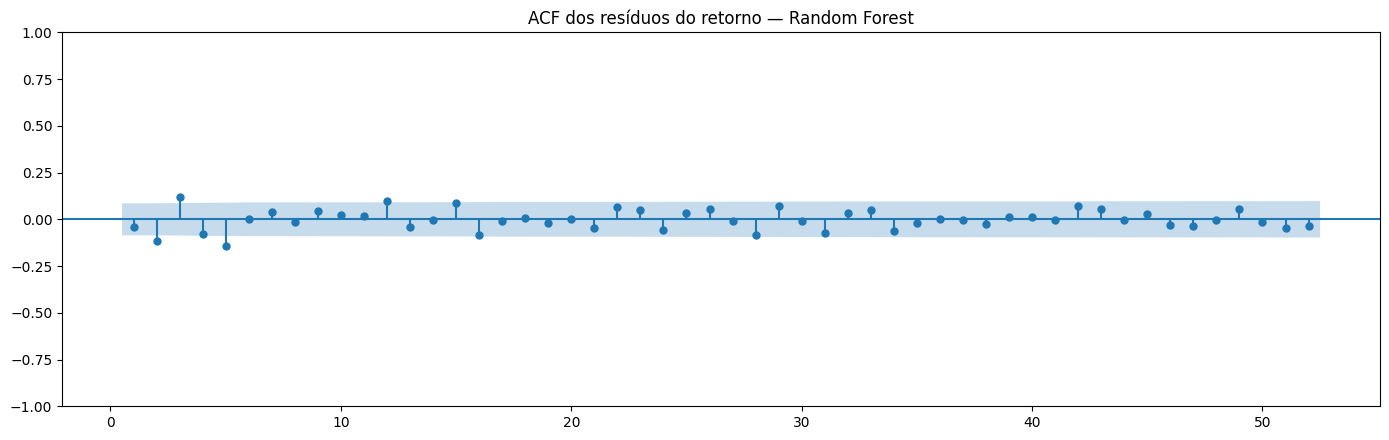

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,0.894967,0.344135,False
4,19.237104,0.000706,True
13,38.756441,0.000219,True
26,55.690168,0.000619,True


In [14]:
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=52, zero=False, ax=ax)
ax.set_title('ACF dos resíduos do retorno — Random Forest')
plt.tight_layout(); plt.show()
ljung_box = acorr_ljungbox(residuals, lags=[1, 4, 13, 26], return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)

## 13. Previsões e métricas do preço do ouro

O modelo continua sendo ajustado sobre o retorno logarítmico, mas esta seção
expõe sua saída final na unidade de interesse: o preço do ouro da semana
seguinte. Todas as linhas abaixo são previsões fora da amostra do walk-forward.

Métricas de erro do preço — fora da amostra e com cotação nova:


,modelo,observacoes,MAE_preco,RMSE_preco,MedAE_preco,MAPE_preco_pct,R2_preco,vies_preco_real_menos_previsto,skill_MAE_vs_persistencia
0,Random Forest via retorno,523,21.443066,31.729796,13.926281,2.273147,0.995199,1.557194,-0.009803
1,Persistência,523,21.234895,31.029890,14.000000,2.251740,0.995409,1.819407,0.000000


Previsão de preço mais recente disponível no teste:


,585
data_origem,2014-04-04 00:00:00
data_prevista,2014-04-11 00:00:00
preco_na_origem,1293.5
preco_real,1309.75
preco_previsto_rf,1295.319548
preco_previsto_persistencia,1293.5
tem_cotacao_nova,1
erro_rf,14.430452
erro_absoluto_rf,14.430452
erro_percentual_absoluto_rf_pct,1.101771


Últimas 20 previsões de preço:


,data_origem,data_prevista,preco_na_origem,preco_real,preco_previsto_rf,preco_previsto_persistencia,tem_cotacao_nova,erro_rf,erro_absoluto_rf,erro_percentual_absoluto_rf_pct
566,2013-11-22,2013-11-29,1241.75,1245.25,1242.766406,1241.75,1,2.483594,2.483594,0.199445
567,2013-11-29,2013-12-06,1245.25,1230.75,1246.931921,1245.25,1,-16.181921,16.181921,1.314802
568,2013-12-06,2013-12-13,1230.75,1222.75,1231.877632,1230.75,1,-9.127632,9.127632,0.746484
569,2013-12-13,2013-12-20,1222.75,1195.00,1224.121109,1222.75,1,-29.121109,29.121109,2.436913
570,2013-12-20,2013-12-27,1195.00,1192.75,1195.046384,1195.00,1,-2.296384,2.296384,0.192529
571,2013-12-27,2014-01-03,1192.75,1192.75,1193.496195,1192.75,0,-0.746195,0.746195,0.062561
572,2014-01-03,2014-01-10,1192.75,1232.25,1194.589635,1192.75,1,37.660365,37.660365,3.056228
573,2014-01-10,2014-01-17,1232.25,1241.00,1233.644996,1232.25,1,7.355004,7.355004,0.592668
574,2014-01-17,2014-01-24,1241.00,1259.25,1242.487803,1241.00,1,16.762197,16.762197,1.331125
575,2014-01-24,2014-01-31,1259.25,1246.50,1261.364126,1259.25,1,-14.864126,14.864126,1.192469


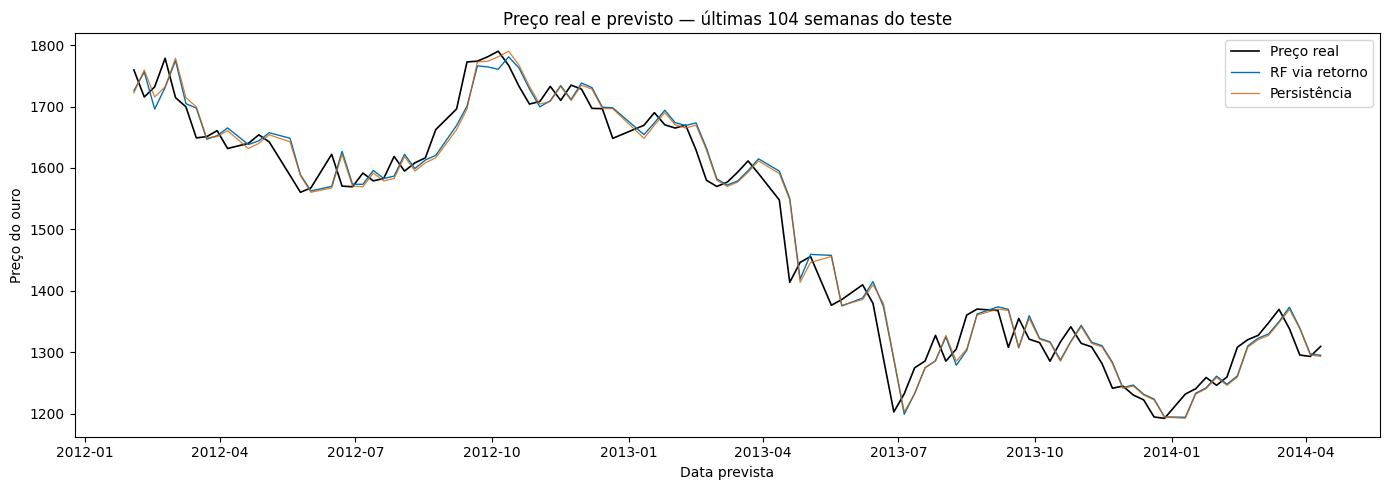

In [15]:
price_forecasts = predictions[[
    'DATE', 'target_date', 'price_t', 'target_price_t_plus_1',
    'price_pred_rf', 'price_pred_persistence', 'target_has_new_quote',
]].copy()
price_forecasts = price_forecasts.rename(columns={
    'DATE': 'data_origem',
    'target_date': 'data_prevista',
    'price_t': 'preco_na_origem',
    'target_price_t_plus_1': 'preco_real',
    'price_pred_rf': 'preco_previsto_rf',
    'price_pred_persistence': 'preco_previsto_persistencia',
    'target_has_new_quote': 'tem_cotacao_nova',
})
price_forecasts['erro_rf'] = price_forecasts.preco_real - price_forecasts.preco_previsto_rf
price_forecasts['erro_absoluto_rf'] = price_forecasts.erro_rf.abs()
price_forecasts['erro_percentual_absoluto_rf_pct'] = (
    100 * price_forecasts.erro_absoluto_rf / price_forecasts.preco_real
)


def price_metric_row(name, values):
    mask = price_forecasts.tem_cotacao_nova.eq(1)
    actual = price_forecasts.loc[mask, 'preco_real']
    predicted = np.asarray(values)[mask.to_numpy()]
    return {
        'modelo': name,
        'observacoes': len(actual),
        'MAE_preco': mean_absolute_error(actual, predicted),
        'RMSE_preco': mean_squared_error(actual, predicted) ** .5,
        'MedAE_preco': median_absolute_error(actual, predicted),
        'MAPE_preco_pct': np.mean(np.abs((actual - predicted) / actual)) * 100,
        'R2_preco': r2_score(actual, predicted),
        'vies_preco_real_menos_previsto': np.mean(actual - predicted),
    }


price_error_metrics = pd.DataFrame([
    price_metric_row('Random Forest via retorno', price_forecasts.preco_previsto_rf),
    price_metric_row('Persistência', price_forecasts.preco_previsto_persistencia),
])
baseline_mae_price = price_error_metrics.loc[
    price_error_metrics.modelo.eq('Persistência'), 'MAE_preco'
].iloc[0]
price_error_metrics['skill_MAE_vs_persistencia'] = (
    1 - price_error_metrics.MAE_preco / baseline_mae_price
)

print('Métricas de erro do preço — fora da amostra e com cotação nova:')
display(price_error_metrics)
print('Previsão de preço mais recente disponível no teste:')
display(price_forecasts.tail(1).T)
print('Últimas 20 previsões de preço:')
display(price_forecasts.tail(20))

plot_data = price_forecasts.loc[price_forecasts.tem_cotacao_nova.eq(1)].tail(104)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_data.data_prevista, plot_data.preco_real, label='Preço real', color='black', lw=1.2)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_rf,
        label='RF via retorno', color='#0072b2', lw=1)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_persistencia,
        label='Persistência', color='#d55e00', lw=.9, alpha=.8)
ax.set(title='Preço real e previsto — últimas 104 semanas do teste',
       xlabel='Data prevista', ylabel='Preço do ouro')
ax.legend()
plt.tight_layout(); plt.show()